Cellule 1 — Imports

In [ ]:
# ===============================
# Cellule 1 — Imports & Token
# ===============================

import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib



from datasets import load_dataset
from PIL import Image

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Charger les variables d'environnement (.env)
load_dotenv()

# Récupérer le token Hugging Face
hf_token = os.getenv("KEY_HUGGING_FACE")

if hf_token is None:
    raise ValueError("HF token not found. Vérifie ton fichier .env")

print("Token loaded successfully!")

Token loaded successfully!


Cellule 2 — Charger dataset privé

In [30]:
# ===============================
# Cellule 2 — Load Dataset
# ===============================

print("Loading dataset from HuggingFace...")

dataset = load_dataset(
    "PAR8/chest-xray-pneumonia",
    token=hf_token
)

train_data = dataset["train"]
val_data   = dataset["validation"]
test_data  = dataset["test"]

print("\nDataset loaded successfully!")
print(f"Train: {len(train_data)} images")
print(f"Validation: {len(val_data)} images")
print(f"Test: {len(test_data)} images")

Loading dataset from HuggingFace...

Dataset loaded successfully!
Train: 4705 images
Validation: 522 images
Test: 624 images


Cellule 3 — Preprocessing 3 classes

In [31]:
# ===============================
# Cellule 3 — Preprocessing (images -> features)
# ===============================

IMG_SIZE = (128, 128)
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]  # 0,1,2

def preprocess_split(split):
    """
    Transforme un split HuggingFace en matrices X (features) et y (labels).
    Étapes :
    - Conversion en niveaux de gris
    - Redimensionnement
    - Normalisation [0,1]
    - Flatten en vecteur
    """
    X = []
    y = []

    for example in split:
        img = example["image"]

        # Sécurité : s'assurer que c'est bien une image PIL
        if not isinstance(img, Image.Image):
            continue

        img = img.convert("L")            # grayscale
        img = img.resize(IMG_SIZE)        # resize
        arr = np.array(img, dtype=np.float32) / 255.0

        X.append(arr.flatten())
        y.append(example["label"])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y


print("Preprocessing splits...")

X_train, y_train = preprocess_split(train_data)
X_val, y_val     = preprocess_split(val_data)
X_test, y_test   = preprocess_split(test_data)

print("\nShapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape, "distribution:", np.unique(y_train, return_counts=True))

print("X_val:", X_val.shape)
print("y_val:", y_val.shape, "distribution:", np.unique(y_val, return_counts=True))

print("X_test:", X_test.shape)
print("y_test:", y_test.shape, "distribution:", np.unique(y_test, return_counts=True))

Preprocessing splits...

Shapes:
X_train: (4705, 16384)
y_train: (4705,) distribution: (array([0, 1, 2]), array([1175, 2362, 1168]))
X_val: (522, 16384)
y_val: (522,) distribution: (array([0, 1, 2]), array([174, 174, 174]))
X_test: (624, 16384)
y_test: (624,) distribution: (array([0, 1, 2]), array([234, 242, 148]))


Cellule 4 — Standardisation

In [32]:
# ===============================
# Cellule 4 — StandardScaler
# ===============================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling done!")
print("X_train_s:", X_train_s.shape)

Scaling done!
X_train_s: (4705, 16384)


Cellule 5 — Entraînement Logistic Regression

In [33]:
# ===============================
# Cellule 5 — Logistic Regression (multiclass)
# ===============================

model = LogisticRegression(
    max_iter=5000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1
)

print("Training Logistic Regression (3 classes)...")
model.fit(X_train_s, y_train)
print("Training done!")

Training Logistic Regression (3 classes)...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done!


Cellule 6 — Évaluation + métriques

In [34]:
# ===============================
# Cellule 6 — Evaluation (metrics + report)
# ===============================

def evaluate_multiclass(name, model, Xs, y_true, class_names):
    y_pred = model.predict(Xs)
    y_proba = model.predict_proba(Xs)  # shape (n,3)

    # Metrics (macro = moyenne non pondérée sur les classes)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

    # ROC-AUC multi-classe (OVR)
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    auc = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")

    print(f"\n===== {name} =====")
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names, digits=4))

    scores = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }
    print("\nScores:")
    for k, v in scores.items():
        print(f"- {k}: {v:.4f}")

    return scores

scores_val = evaluate_multiclass("VALIDATION", model, X_val_s, y_val, CLASS_NAMES)
scores_test = evaluate_multiclass("TEST", model, X_test_s, y_test, CLASS_NAMES)


===== VALIDATION =====
Confusion matrix:
 [[162   4   8]
 [  6 127  41]
 [  9  62 103]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9153    0.9310    0.9231       174
    BACTERIA     0.6580    0.7299    0.6921       174
       VIRUS     0.6776    0.5920    0.6319       174

    accuracy                         0.7510       522
   macro avg     0.7503    0.7510    0.7490       522
weighted avg     0.7503    0.7510    0.7490       522


Scores:
- Accuracy: 0.7510
- Precision: 0.7503
- Recall: 0.7510
- F1-score: 0.7490
- ROC-AUC: 0.8938

===== TEST =====
Confusion matrix:
 [[102  51  81]
 [  5 205  32]
 [  4  60  84]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9189    0.4359    0.5913       234
    BACTERIA     0.6487    0.8471    0.7348       242
       VIRUS     0.4264    0.5676    0.4870       148

    accuracy                         0.6266       624
   macro avg     0.6647

Cellule 7 — Graphique barres en %

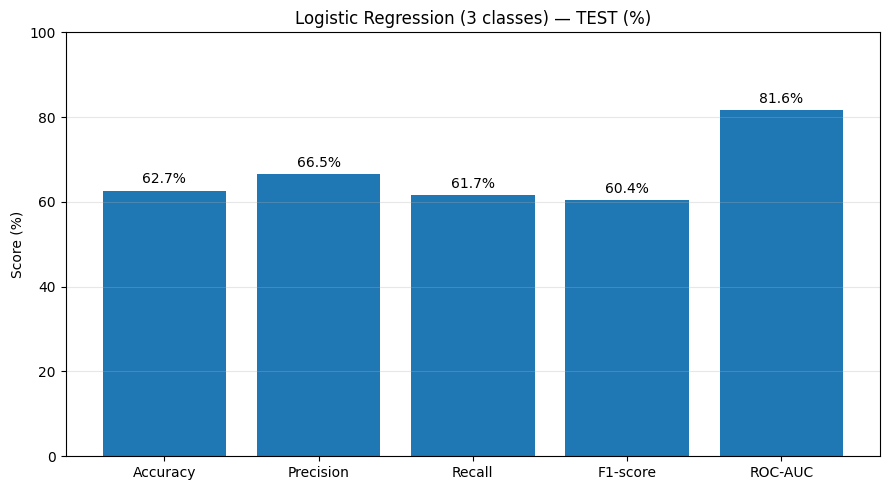

In [35]:
# ===============================
# Cellule 7 — Bar chart (%)
# ===============================

def plot_scores(scores, title):
    labels = list(scores.keys())
    values = [scores[k] * 100 for k in labels]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, values)
    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, val + 1, f"{val:.1f}%", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

plot_scores(scores_test, "Logistic Regression (3 classes) — TEST (%)")

Cellule 8 — PCA + Logistic Regression

PCA dims: 16384 -> 383
Training Logistic Regression + PCA...


/Users/williamleite/Documents/projetepitech/pneumonia_logreg/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done!

===== TEST (PCA) =====
Confusion matrix:
 [[ 88  34 112]
 [  4 217  21]
 [  5  31 112]]

Classification report:
               precision    recall  f1-score   support

      NORMAL     0.9072    0.3761    0.5317       234
    BACTERIA     0.7695    0.8967    0.8282       242
       VIRUS     0.4571    0.7568    0.5700       148

    accuracy                         0.6683       624
   macro avg     0.7113    0.6765    0.6433       624
weighted avg     0.7471    0.6683    0.6558       624


Scores:
- Accuracy: 0.6683
- Precision: 0.7113
- Recall: 0.6765
- F1-score: 0.6433
- ROC-AUC: 0.8604


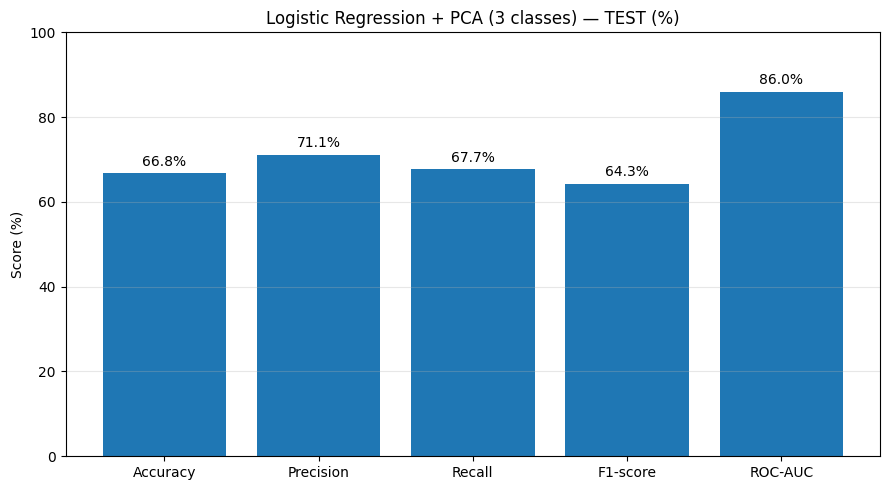

In [36]:
# ===============================
# Cellule 8 — PCA + Logistic Regression
# ===============================

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_s)
X_val_pca   = pca.transform(X_val_s)
X_test_pca  = pca.transform(X_test_s)

print("PCA dims:", X_train_s.shape[1], "->", X_train_pca.shape[1])

model_pca = LogisticRegression(
    max_iter=5000,
    solver="saga",
    multi_class="multinomial",
    class_weight="balanced",
    n_jobs=-1
)

print("Training Logistic Regression + PCA...")
model_pca.fit(X_train_pca, y_train)
print("Training done!")

scores_test_pca = evaluate_multiclass("TEST (PCA)", model_pca, X_test_pca, y_test, CLASS_NAMES)
plot_scores(scores_test_pca, "Logistic Regression + PCA (3 classes) — TEST (%)")

Cellule 9 — Comparaison (Pixels vs PCA) + sauvegarde

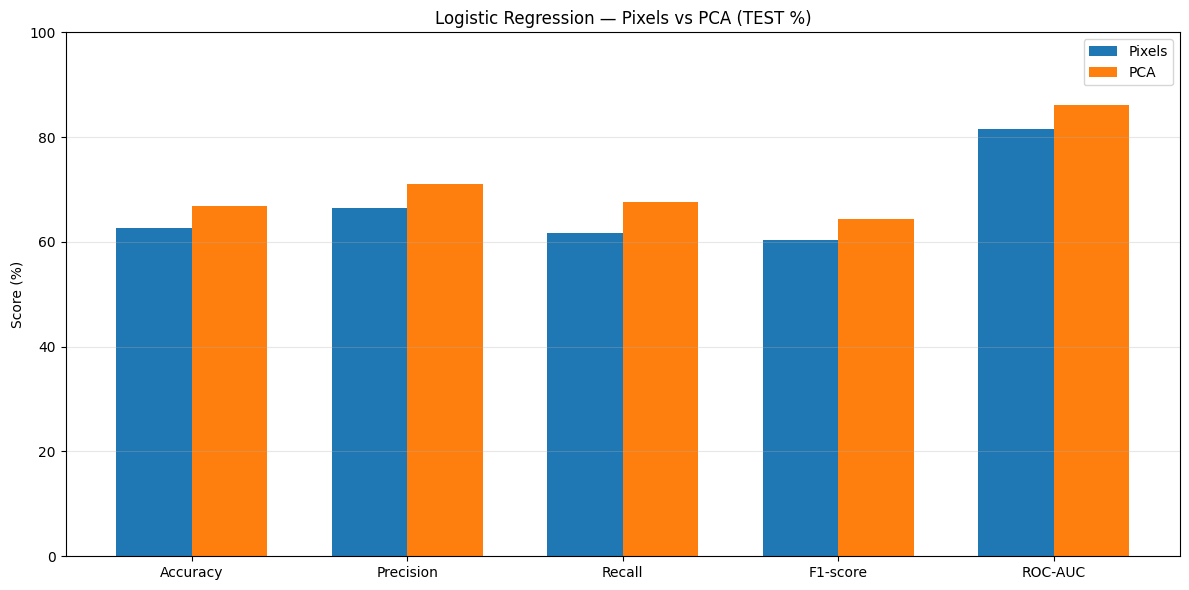

Saved: logreg_3classes_pixels.pkl, logreg_3classes_pca.pkl, scaler.pkl, pca.pkl


In [37]:
# ===============================
# Cellule 9 — Compare + Save
# ===============================

def compare_models_bar(models_scores, title="Comparaison modèles (TEST %)"):
    metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
    names = list(models_scores.keys())

    x = np.arange(len(metrics))
    width = 0.35 if len(names) == 2 else 0.25

    plt.figure(figsize=(12, 6))
    for i, name in enumerate(names):
        vals = [models_scores[name][m] * 100 for m in metrics]
        plt.bar(x + i * width, vals, width=width, label=name)

    plt.xticks(x + width * (len(names)-1)/2, metrics)
    plt.ylim(0, 100)
    plt.ylabel("Score (%)")
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_models_bar(
    {"Pixels": scores_test, "PCA": scores_test_pca},
    "Logistic Regression — Pixels vs PCA (TEST %)"
)

# Sauvegarde
joblib.dump(model, "logreg_3classes_pixels.pkl")
joblib.dump(model_pca, "logreg_3classes_pca.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

print("Saved: logreg_3classes_pixels.pkl, logreg_3classes_pca.pkl, scaler.pkl, pca.pkl")